### Step 2: Data Audit, Cleaning, and Dataset Splitting (Student 2)
As **Student 2**, we perform initial data cleaning and split the dataset into three parts before applying preprocessing to prevent data leakage[cite: 1, 2]:
- **Train Set**: 50%
- **Validation Set**: 25%
- **Test Set**: 25%

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Load dataset & remove duplicate rows
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv').drop_duplicates().reset_index(drop=True)

# 2. Separate features (X) and target (y)
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

# 3. First Split: 25% Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Second Split: 50% Train set and 25% Validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

# Print split summary
total = len(df)
print(f"Train Set:      {len(X_train)} rows ({len(X_train)/total*100:.1f}%)")
print(f"Validation Set: {len(X_val)} rows ({len(X_val)/total*100:.1f}%)")
print(f"Test Set:       {len(X_test)} rows ({len(X_test)/total*100:.1f}%)")

Train Set:      114890 rows (50.0%)
Validation Set: 57445 rows (25.0%)
Test Set:       57446 rows (25.0%)


### Visualizing Dataset Splits
We plot the proportions of Train, Validation, and Test sets to verify the 50/25/25 split ratio.

C:\Users\nilof\AppData\Local\Temp\ipykernel_8668\137143029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), palette='Blues_d')


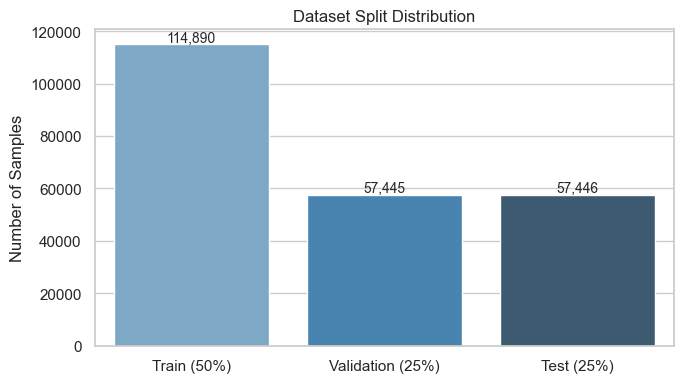

In [3]:
# Bar plot for Train / Validation / Test split
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

split_sizes = {'Train (50%)': len(X_train), 'Validation (25%)': len(X_val), 'Test (25%)': len(X_test)}
ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), palette='Blues_d')

plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis: Target Class Distribution
We check the target variable balance in the training set.

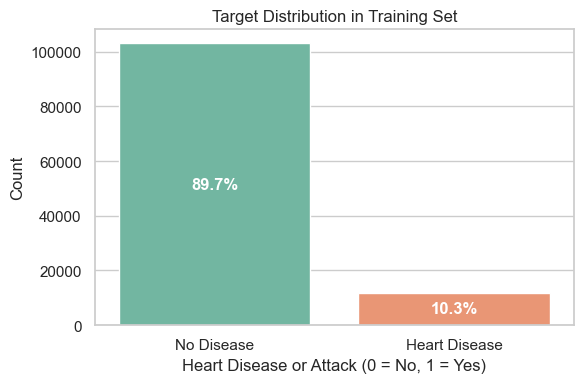

In [4]:
# Target distribution in training set
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, hue=y_train, palette='Set2', legend=False)
plt.title('Target Distribution in Training Set')
plt.xlabel('Heart Disease or Attack (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])

# Annotate percentages
total_train = len(y_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_train:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()